### <b>library

In [20]:
# basic
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# pytorch core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset

# pytorch data
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# utility
from tqdm.auto import tqdm

# model library
import timm

# device setup
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

device: cuda:0


### <b>augmentasi, split, load

In [2]:
# path
TRAIN_PATH = '../data/cropped'

BATCH_SIZE = 4
EPOCHS = 20
LEARNING_RATE = 3e-4
IMG_SIZE = 224

classes = ['realperson', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_mannequin', 'fake_unknown']

In [3]:
# augmentasi
train_transform = transforms.Compose([
    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),

    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

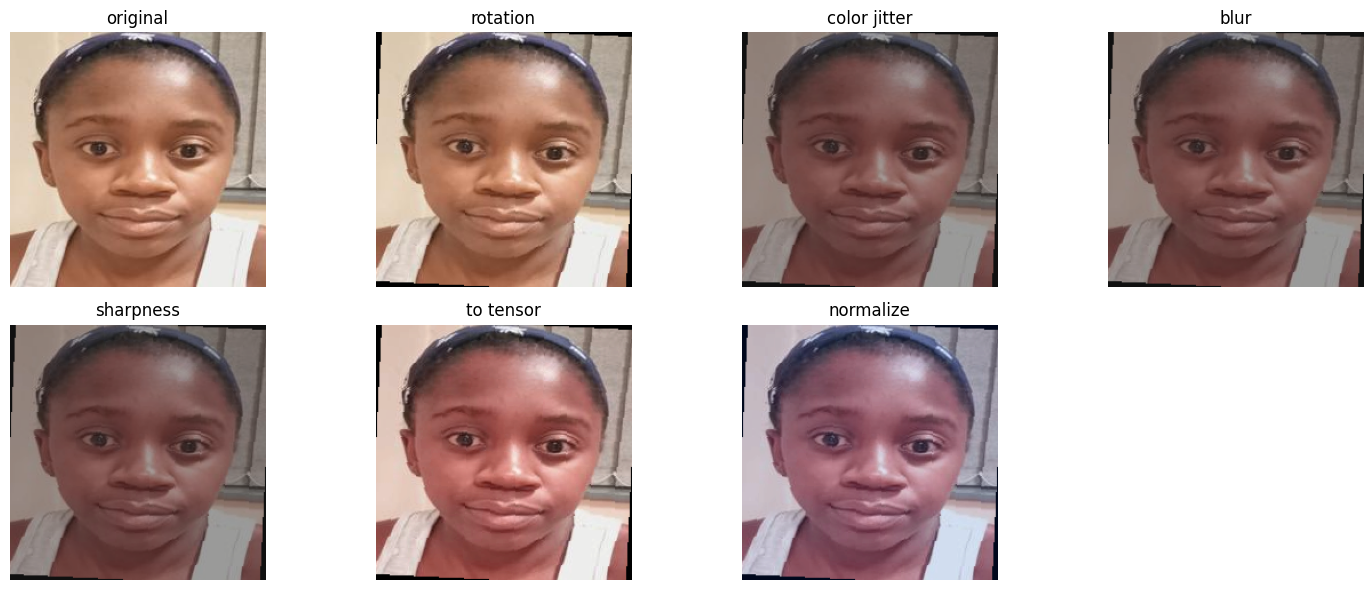

In [4]:
# cek 1 foto

img = Image.open("../data/cropped/realperson/real_002.jpg").convert("RGB")

# definisikan step dengan format konsisten
steps = [
    ("original", None),

    ("rotation", transforms.RandomRotation(10)),

    ("color jitter", transforms.ColorJitter(
        brightness=0.3,
        contrast=0.2,
        saturation=0.3,
        hue=0.05
    )),

    ("blur", transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))),

    ("sharpness", transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3)),

    ("to tensor", transforms.ToTensor()),

    ("normalize", transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ))
]

def tensor_to_img(t):
    t = t.clone().detach()
    if t.shape[0] == 3:
        t = t.permute(1, 2, 0)
    t = t.numpy()
    t = (t - t.min()) / (t.max() - t.min() + 1e-5)
    return t

current = img
results = []

for name, transform in steps:
    if transform is not None:
        current = transform(current)
    results.append((name, current))

plt.figure(figsize=(15, 6))

for i, (name, im) in enumerate(results):
    plt.subplot(2, 4, i+1)

    if isinstance(im, Image.Image):
        plt.imshow(im)
    else:
        plt.imshow(tensor_to_img(im))

    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# dataset TANPA transform dulu
full_dataset = datasets.ImageFolder(
    root=TRAIN_PATH
)

class_names = full_dataset.classes

# split index
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(
    range(len(full_dataset)),
    [train_size, val_size],
    generator=generator
)

# buat dataset terpisah
train_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=TRAIN_PATH, transform=train_transform),
    train_indices.indices
)

val_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=TRAIN_PATH, transform=val_transform),
    val_indices.indices
)

In [7]:
# dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,        
    pin_memory=True        
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Data --> Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Data --> Train: 1176, Val: 295


## <b>MODEL

1. Set seed
2. Model
3. Loss
4. Optimizer
5. Scheduler
6. AMP
7. Train setup
8. Validation
9. Save best model<br><br>
10. Load best model
11. Predict test

In [8]:
# 1. set seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

### <b>model 1 (efficientnet_b3)

In [9]:
# 2. model
model = timm.create_model(
    'efficientnet_b3',
    pretrained=True,
    num_classes=len(classes),
    drop_rate=0.3
)
model = model.to(device)

# 3. loss
criterion = nn.CrossEntropyLoss()

# 4. optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

# 5. scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# 6. amp
scaler = torch.amp.GradScaler('cuda')

In [10]:
# 7. train setup
train_losses, val_losses, val_accuracies = [], [], []
best_val_acc = 0.0

patience = 3
patience_counter = 0

model_dir = '../models/'
os.makedirs(model_dir, exist_ok=True)
model_save_path = os.path.join(model_dir, 'efficientnet_b3_model.pth')

# 8. training + validation
print("Training...")

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    running_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)

        current_lr = scheduler.get_last_lr()[0]
        train_pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'lr': f"{current_lr:.6f}"
        })

    scheduler.step()

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]')
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = correct / total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # 9. save best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), model_save_path)
        print(f"Model terbaik disimpan! Acc: {best_val_acc:.4f}")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"No improvement: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

print(f"\nTraining selesai. Best Acc: {best_val_acc:.4f}")

Training...


Epoch 1/20 [Train]:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 1/20 [Val]: 100%|██████████| 74/74 [00:53<00:00,  1.39it/s] 


Epoch 1 | Train Loss: 1.8050 | Val Loss: 3.7412 | Val Acc: 0.6339
Model terbaik disimpan! Acc: 0.6339


Epoch 2/20 [Val]: 100%|██████████| 74/74 [00:54<00:00,  1.36it/s] 


...

Epoch 8 | Train Loss: 0.1285 | Val Loss: 0.9013 | Val Acc: 0.8102
No improvement: 1/3


Epoch 9/20 [Val]: 100%|██████████| 74/74 [01:17<00:00,  1.05s/it] 


Epoch 9 | Train Loss: 0.1236 | Val Loss: 0.6332 | Val Acc: 0.8475
No improvement: 2/3


Epoch 10/20 [Val]: 100%|██████████| 74/74 [01:00<00:00,  1.22it/s] 

Epoch 10 | Train Loss: 0.0954 | Val Loss: 0.6308 | Val Acc: 0.8542
No improvement: 3/3
Early stopping triggered

Training selesai. Best Acc: 0.8576


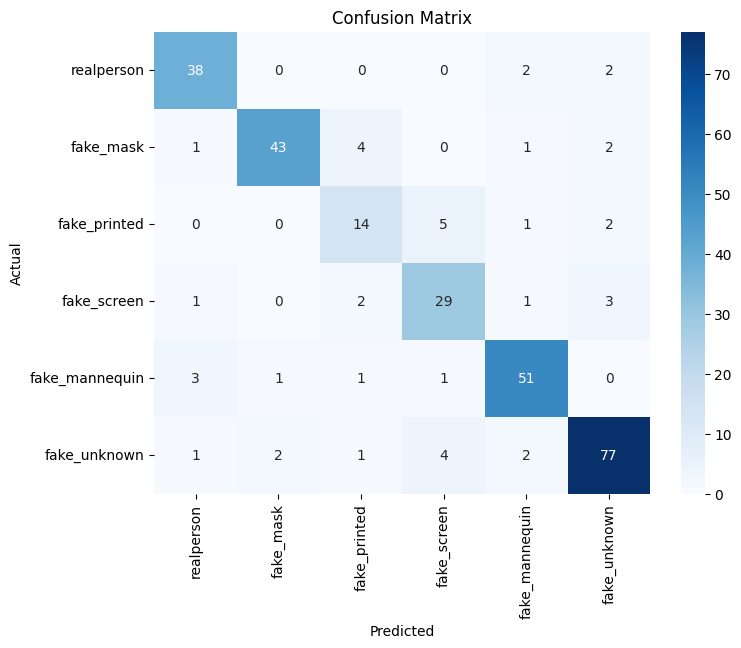


===== METRICS =====
Accuracy  : 0.8542
Precision : 0.8255
Recall    : 0.8283
F1 Score  : 0.8262

===== CLASSIFICATION REPORT =====
                precision    recall  f1-score   support

    realperson       0.86      0.90      0.88        42
     fake_mask       0.93      0.84      0.89        51
  fake_printed       0.64      0.64      0.64        22
   fake_screen       0.74      0.81      0.77        36
fake_mannequin       0.88      0.89      0.89        57
  fake_unknown       0.90      0.89      0.89        87

      accuracy                           0.85       295
     macro avg       0.83      0.83      0.83       295
  weighted avg       0.86      0.85      0.85       295



In [11]:
# metrik evaluasi

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# basic metrics
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print("\n===== METRICS =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# detail per class
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(all_labels, all_preds, target_names=classes))

### <b>predict

In [ ]:
# load model
model_path = '../models/efficientnet_b3_model.pth'

best_model = timm.create_model(
    'efficientnet_b3',
    pretrained=False,
    num_classes=len(classes),
    drop_rate=0.3
)

best_model.load_state_dict(torch.load(model_path, map_location=device))
best_model = best_model.to(device)
best_model.eval()

print("Best model loaded dari:", model_path)

Best model loaded dari: ../models/efficientnet_b3_model.pth


In [30]:
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_names = sorted(os.listdir(root_dir))  # penting biar urut

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.root_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_name
    
TEST_PATH = '../data/cropped_test'

test_dataset = TestDataset(TEST_PATH, transform=val_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Test data: {len(test_dataset)}")

Test data: 404


In [28]:
results = []

with torch.no_grad():
    for inputs, img_names in tqdm(test_loader, desc="Predicting"):
        inputs = inputs.to(device)

        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)

        for name, pred in zip(img_names, preds):
            label = classes[pred.item()]
            results.append((name, label))

Predicting: 100%|██████████| 101/101 [00:05<00:00, 18.17it/s]


In [31]:
df = pd.DataFrame(results, columns=["id", "label"])

# hilangin .jpg kalau perlu
df["id"] = df["id"].str.replace(r"\.(jpg|jpeg|png)$", "", regex=True)

# urutin (biar test_001, test_002, ...)
df = df.sort_values("id")

df.to_csv("submission.csv", index=False)

print("Submission berhasil dibuat!")

Submission berhasil dibuat!
